## Import data


In [15]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)

all_features = [
    "mean_p_tcr_pae",
    "mean_tcr_p_pae",
    "mean_mhc_tcr_pae",
    "mean_tcr_mhc_pae",
    "mean_p_mhc_pae",
    "tcr_mhc_contacts",
    "peptide_tcr_contacts",
    "chain_iptm",
    "chain_pair_iptm",
    "chain_pair_pae_min",
    "chain_ptm",
    "fraction_disordered",
    "has_clash",
    "iptm",
    "ptm",
    "ranking_score",
    "peptide_mean_pLDDT",
    "tcr_1_cdr_1_mean_pLDDT",
    "tcr_1_cdr_2_mean_pLDDT",
    "tcr_1_cdr_2_5_mean_pLDDT",
    "tcr_1_cdr_3_mean_pLDDT",
    "tcr_2_cdr_1_mean_pLDDT",
    "tcr_2_cdr_2_mean_pLDDT",
    "tcr_2_cdr_2_5_mean_pLDDT",
    "tcr_2_cdr_3_mean_pLDDT",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
    "mean_p_tcr_pae_II",
    "mean_tcr_p_pae_II",
    "mean_mhc_tcr_pae_II",
    "mean_tcr_mhc_pae_II",
    "peptide_mean_pLDDT_II",
]


cresta_conf = pl.read_parquet("../../data/cresta/triad/cresta_triad.conf_af3.parquet")
cresta_tcrdock = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.af3_tcrdock.parquet"
)
cresta = cresta_conf.join(
    cresta_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)


template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, cresta_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(cresta.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

cresta = cresta.with_columns(pl.Series(name="p_dgeom", values=cresta_p_dgeom))

## Plotting methods


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS
from tcrtrifold.eval_utils import antigen_raw_score_auc
import sklearn.metrics as metrics
from scipy.stats import mannwhitneyu, norm, false_discovery_control
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict, defaultdict


def plot_dist_auc_per_win(auc_df, title=None):
    box_df = auc_df.group_by("antigen_name", "orig_peptide").agg(
        pl.col("roc_auc").alias("roc_auc_per_window"),
        pl.col("peptide"),
        pl.col("mhc_2_name").first(),
    )

    x = np.arange(box_df.height)
    width = 0.3
    fig, ax = plt.subplots(figsize=(8, 5))

    antigen_display = []

    for i, row in enumerate(box_df.iter_rows(named=True)):
        rocs = row["roc_auc_per_window"]
        peptides = row["peptide"]
        original_peptide = row["orig_peptide"]
        antigen_display.append(original_peptide + "\n" + row["mhc_2_name"])

        ax.boxplot(rocs, positions=[x[i]], widths=width, showfliers=False)

        # print(original_peptide)
        # print(len(original_peptide))
        # print([original_peptide.index(p) for p in peptides])
        x_idx = [
            x[i]
            + (((original_peptide.index(p) / (len(original_peptide) - 9)) * 0.5) - 0.25)
            for p in peptides
        ]

        ax.scatter(
            x_idx,
            rocs,
            alpha=0.6,
            color="green",
            s=30,
            edgecolor="black",
        )

        idx_max = np.argmax(rocs)
        y_max = rocs[idx_max]
        pep_max = peptides[idx_max]

        ax.text(
            x_idx[idx_max],
            y_max + 0.01,
            pep_max,
            fontsize=8,
            rotation=45,
            ha="left",
            va="bottom",
        )

    # mhc_name = box_df.select("mhc_2_name").to_series().to_list()

    ax.set_xticks(x)
    ax.set_xticklabels(antigen_display, rotation=45, ha="right")
    ax.set_ylabel("Distribution of ROC AUC for 9mer windows")

    if title:
        ax.set_title(title)

    plt.tight_layout()
    return fig


def plot_correlation(
    x: np.ndarray,
    y: np.ndarray,
    xlabel: str,
    ylabel: str,
    *,
    color_label: np.ndarray[str] | None = None,
    method: str = "spearman",
    title: str | None = None,
) -> plt.Figure:
    """
    Scatter-plot x vs y, compute Pearson or Spearman r/p,
    and optionally color points by a string array of labels.
    """
    # -- compute overall correlation
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    fig, ax = plt.subplots()

    if color_label is not None:
        labels = np.asarray(color_label)
        unique_labels = np.unique(labels)
        cmap = plt.get_cmap("tab10")
        # for i, lbl in enumerate(unique_labels):
        #     mask = labels == lbl
        #     ax.scatter(
        #         x[mask],
        #         y[mask],
        #         label=str(lbl),
        #         color=cmap(i % cmap.N),
        #         alpha=0.8,
        #         edgecolors="black",
        #         linewidth=0.5,
        #     )
        for i, lbl in enumerate(unique_labels):
            mask = labels == lbl
            xi, yi = x[mask], y[mask]

            order = np.argsort(xi)
            ax.plot(
                xi[order],
                yi[order],
                linestyle="-",
                color=cmap(i % cmap.N),
                alpha=0.7,
                linewidth=1,
            )

            ax.scatter(
                xi,
                yi,
                label=str(lbl),
                color=cmap(i % cmap.N),
                alpha=0.8,
                edgecolors="w",
                linewidth=0.5,
            )
        ax.legend(title="Label", loc="best", framealpha=0.7, fontsize="x-small")
    else:
        ax.scatter(
            x,
            y,
            color="blue",
            alpha=0.8,
            edgecolors="black",
            linewidth=0.5,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    ax.text(
        0.05,
        0.95,
        f"{method.title()} r = {r:.2f}, p = {p:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )

    plt.tight_layout()
    return fig


def auc_by(df, featnames, feat_type, grouping_cols=FORMAT_ANTIGEN_COLS):

    antigen_st = df.filter(pl.col("cognate")).select(grouping_cols).unique()

    feat_df = []

    for row in antigen_st.iter_rows(named=True):

        focal_a_st = pl.DataFrame([row]).select(pl.exclude("job_name"))
        focal_pos = df.join(focal_a_st, on=grouping_cols)
        focal_neg = df.join(
            focal_pos.select(FORMAT_ANTIGEN_COLS).unique(),
            on=FORMAT_ANTIGEN_COLS,
        ).filter(~pl.col("cognate"))

        focal_triad = pl.concat([focal_pos, focal_neg])

        for feat, ft in zip(featnames, feat_type):
            dat = focal_triad.select(feat, "cognate").to_numpy()

            fpr, tpr, threshold = metrics.roc_curve(dat[:, 1], dat[:, 0])
            # roc_auc = abs(metrics.auc(fpr, tpr) - 0.5) + 0.5
            roc_auc = metrics.auc(fpr, tpr)

            feat_df.append(
                {
                    "auc": roc_auc,
                    # "fpr": list(fpr),
                    # "tpr": list(tpr),
                    "featname": feat,
                    "feat_type": ft,
                }
            )

    feat_df = pl.DataFrame(feat_df)

    return feat_df


docking_feats = [
    "d",
    "mhc_unit_y",
    "mhc_unit_z",
    "tcr_unit_y",
    "tcr_unit_z",
    "torsion",
    "p_dgeom",
]

interface_feats = [
    "mean_p_tcr_pae",
    "mean_tcr_p_pae",
    "mean_mhc_tcr_pae",
    "mean_tcr_mhc_pae",
    "mean_p_tcr_contact_prob",
    "mean_tcr_p_contact_prob",
    "mean_mhc_tcr_contact_prob",
    "mean_tcr_mhc_contact_prob",
    "mean_p_tcr_interface_pae",
    "mean_tcr_p_interface_pae",
    "mean_tcr_pmhc_interface_pae",
    "mean_pmhc_tcr_interface_pae",
    "mean_p_tcr_interface_contact_prob",
    "mean_tcr_p_interface_contact_prob",
    "mean_tcr_pmhc_interface_contact_prob",
    "mean_pmhc_tcr_interface_contact_prob",
    "mean_p_mhc_pae",
    "mean_mhc_p_pae",
    "mean_mhc_p_interface_pae",
    "mean_p_mhc_interface_pae",
    # "mean_mhc_p_contact_prob",
    # "mean_p_mhc_contact_prob",
    "min_p_tcr_pae",
    "min_mhc_tcr_pae",
    "min_tcr_p_pae",
    "min_tcr_mhc_pae",
    "tcr_mhc_contacts",
    "tcr_p_contacts",
]


local_feats_II = [
    "peptide_mean_pLDDT",
    "peptide_mean_pLDDT_II",
    "tcr_1_cdr_1_mean_pLDDT",
    "tcr_1_cdr_2_mean_pLDDT",
    "tcr_1_cdr_2_5_mean_pLDDT",
    "tcr_1_cdr_3_mean_pLDDT",
    "tcr_2_cdr_1_mean_pLDDT",
    "tcr_2_cdr_2_mean_pLDDT",
    "tcr_2_cdr_2_5_mean_pLDDT",
    "tcr_2_cdr_3_mean_pLDDT",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
]


local_feats_I = [
    "peptide_mean_pLDDT",
    "tcr_1_cdr_1_mean_pLDDT",
    "tcr_1_cdr_2_mean_pLDDT",
    "tcr_1_cdr_2_5_mean_pLDDT",
    "tcr_1_cdr_3_mean_pLDDT",
    "tcr_2_cdr_1_mean_pLDDT",
    "tcr_2_cdr_2_mean_pLDDT",
    "tcr_2_cdr_2_5_mean_pLDDT",
    "tcr_2_cdr_3_mean_pLDDT",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
]

summary_feats = [
    "iptm",
    "ptm",
    "ranking_score",
]

featnames_II = docking_feats + interface_feats + local_feats_II + summary_feats
feat_type_II = (
    ["docking"] * len(docking_feats)
    + ["interface"] * len(interface_feats)
    + ["local"] * len(local_feats_II)
    + ["summary"] * len(summary_feats)
)

## Cresta unwindowed performance


In [18]:
cresta_by_antigen = auc_by(cresta, featnames_II, feat_type_II)
cresta_by_antigen_agg = (
    cresta_by_antigen.group_by("featname", "feat_type")
    .agg(pl.col("auc").median().alias("median_auc"), pl.col("auc"))
    .sort(by="median_auc", descending=True)
)
pl.Config.set_tbl_rows(-1)
cresta_by_antigen_agg

featname,feat_type,median_auc,auc
str,str,f64,list[f64]
"""peptide_mean_pLDDT_II""","""local""",0.772535,"[0.810553, 0.804142, … 0.75]"
"""tcr_mhc_contacts""","""interface""",0.768612,"[0.789756, 0.793195, … 0.65472]"
"""tcr_cdrs_mean_pLDDT""","""local""",0.763977,"[0.761905, 0.810651, … 0.591409]"
"""peptide_mean_pLDDT""","""local""",0.760111,"[0.814962, 0.801183, … 0.746753]"
"""iptm""","""summary""",0.750712,"[0.822604, 0.836391, … 0.657842]"
"""tcr_1_cdr_1_mean_pLDDT""","""local""",0.747451,"[0.707378, 0.79645, … 0.660589]"
"""ranking_score""","""summary""",0.746736,"[0.820694, 0.839349, … 0.642857]"
"""mhc_helices_mean_pLDDT""","""local""",0.743649,"[0.80629, 0.850296, … 0.734765]"
"""ptm""","""summary""",0.73722,"[0.829879, 0.806213, … 0.651973]"


roc_auc
f64
0.775589


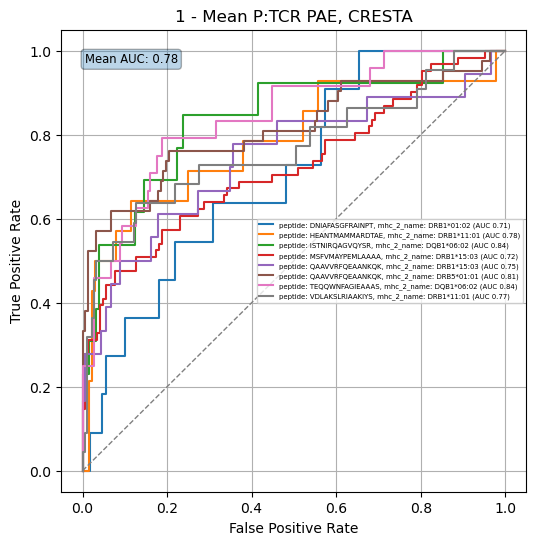

In [7]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    cresta.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(
    auc_df, id_cols=["peptide", "mhc_2_name"], title="1 - Mean P:TCR PAE, CRESTA"
)

auc_df.select(pl.col("roc_auc").median())

roc_auc
f64
0.768612


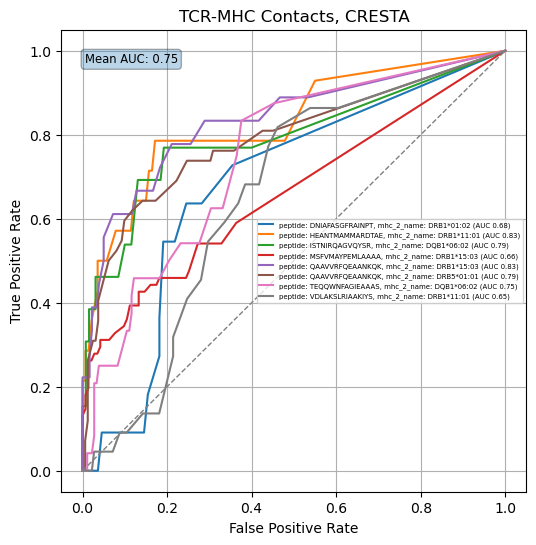

In [ ]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    cresta,
    "tcr_mhc_contacts",
)

plot_auc_per_antigen(
    auc_df, id_cols=["peptide", "mhc_2_name"], title="TCR-MHC Contacts, CRESTA"
)

auc_df.select(pl.col("roc_auc").median())

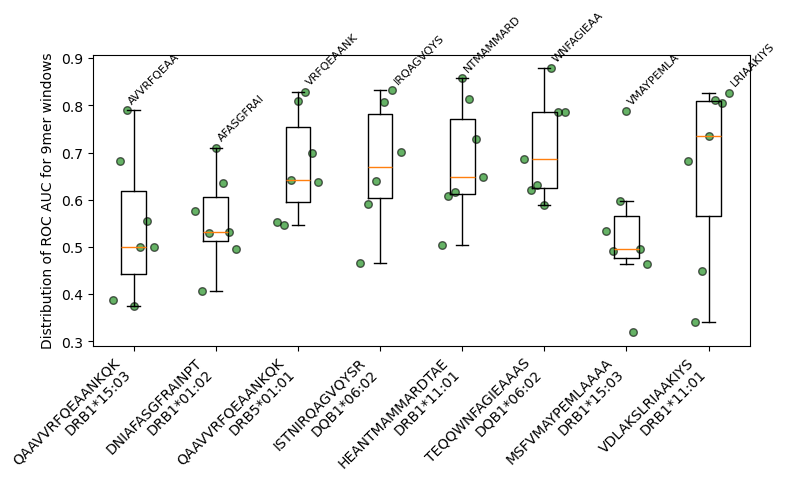

In [44]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
from tcrtrifold.utils import FORMAT_ANTIGEN_COLS

entity_mapping = cresta_w.select(
    FORMAT_ANTIGEN_COLS + ["antigen_name", "orig_peptide"]
).unique()

featname = "mean_p_tcr_pae"

auc_df = antigen_raw_score_auc(
    cresta_w.with_columns((1 - pl.col(featname)).alias(featname)),
    featname,
)

auc_df = auc_df.join(entity_mapping, on=FORMAT_ANTIGEN_COLS)

fig = plot_dist_auc_per_win(auc_df)

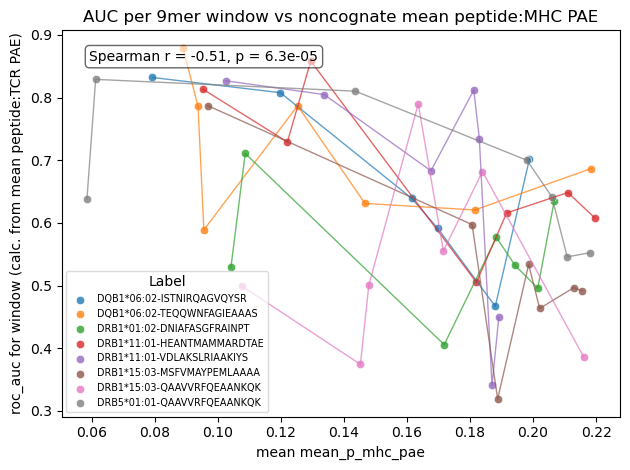

In [45]:
from scipy.stats import spearmanr

featname = "mean_p_mhc_pae"


conf_mean_by_win = (
    cresta_w.filter(~pl.col("cognate"))
    .group_by(FORMAT_ANTIGEN_COLS + ["antigen_name"])
    .agg(pl.col(featname).mean())
)

conf_mean_by_win = auc_df.join(
    conf_mean_by_win, on=FORMAT_ANTIGEN_COLS + ["antigen_name"]
)

orig_partition = conf_mean_by_win.partition_by("antigen_name", "orig_peptide")

all_feat_mean = []
all_auc = []
color_label = []

for p in orig_partition:
    feat_mean = p.select(featname).to_series().to_numpy()
    auc = p.select("roc_auc").to_series().to_numpy()

    all_feat_mean.append(feat_mean)
    all_auc.append(auc)
    color_label.append(
        [f"{p.select('mhc_2_name')[0].item()}-{p.select('orig_peptide')[0].item()}"]
        * len(feat_mean)
    )

    # fig = plot_correlation(
    #     feat_mean,
    #     auc,
    #     xlabel=f"mean {featname}",
    #     ylabel="roc_auc for window (calc. from mean peptide:TCR PAE)",
    #     title=f"{p.select('mhc_2_name')[0].item()}-{p.select('orig_peptide')[0].item()}",
    # )

all_feat_mean = np.concat(all_feat_mean)
all_auc = np.concat(all_auc)
color_label = np.concat(color_label)

fig = plot_correlation(
    all_feat_mean,
    all_auc,
    color_label=color_label,
    xlabel=f"mean {featname}",
    ylabel="roc_auc for window (calc. from mean peptide:TCR PAE)",
    title="AUC per 9mer window vs noncognate mean peptide:MHC PAE",
)

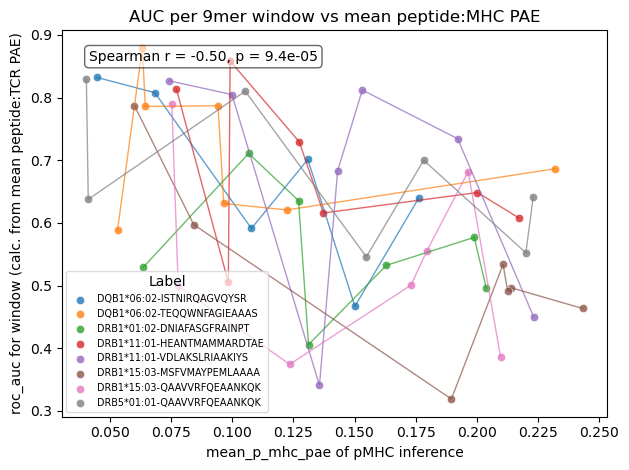

In [102]:
from scipy.stats import spearmanr


conf_mean_by_win = auc_df.join(
    cresta_pmhc_w.select(FORMAT_ANTIGEN_COLS + ["antigen_name", "mean_p_mhc_pae"]),
    on=FORMAT_ANTIGEN_COLS + ["antigen_name"],
)

orig_partition = conf_mean_by_win.partition_by("antigen_name", "orig_peptide")

all_feat_mean = []
all_auc = []
color_label = []

for p in orig_partition:
    feat_mean = p.select(featname).to_series().to_numpy()
    auc = p.select("roc_auc").to_series().to_numpy()

    all_feat_mean.append(feat_mean)
    all_auc.append(auc)
    color_label.append(
        [f"{p.select('mhc_2_name')[0].item()}-{p.select('orig_peptide')[0].item()}"]
        * len(feat_mean)
    )

    # fig = plot_correlation(
    #     feat_mean,
    #     auc,
    #     xlabel=f"mean {featname}",
    #     ylabel="roc_auc for window (calc. from mean peptide:TCR PAE)",
    #     title=f"{p.select('mhc_2_name')[0].item()}-{p.select('orig_peptide')[0].item()}",
    # )

all_feat_mean = np.concat(all_feat_mean)
all_auc = np.concat(all_auc)
color_label = np.concat(color_label)

fig = plot_correlation(
    all_feat_mean,
    all_auc,
    color_label=color_label,
    xlabel=f"{featname} of pMHC inference",
    ylabel="roc_auc for window (calc. from mean peptide:TCR PAE)",
    title="AUC per 9mer window vs mean peptide:MHC PAE",
)

### If we knew the best 9 performing 9mer for each full peptide, what would our performance be?


In [ ]:
best_9mer_auc_df = (
    auc_df.group_by("antigen_name")
    .agg(
        [pl.col("roc_auc"), pl.col("tpr"), pl.col("fpr")]
        + [pl.col(colname) for colname in FORMAT_ANTIGEN_COLS]
    )
    .with_columns(pl.col("roc_auc").list.arg_max().alias("best_9mer_idx"))
    .with_columns(
        [
            pl.col("tpr").list.get(pl.col("best_9mer_idx")).alias("tpr"),
            pl.col("fpr").list.get(pl.col("best_9mer_idx")).alias("fpr"),
            pl.col("roc_auc").list.get(pl.col("best_9mer_idx")).alias("roc_auc"),
        ]
        + [
            pl.col(colname).list.get(pl.col("best_9mer_idx")).alias(colname)
            for colname in FORMAT_ANTIGEN_COLS
        ]
    )
)

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

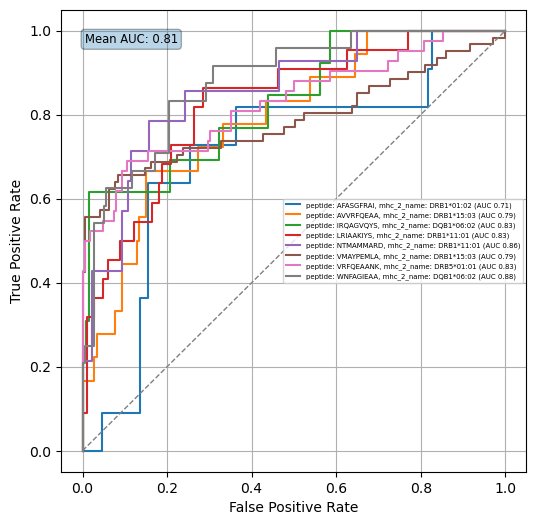

In [58]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

plot_auc_per_antigen(best_9mer_auc_df, id_cols=["peptide", "mhc_2_name"])

### If we selected the peptide window based on PMHC PAE, would we pick the correct one?


In [92]:
pmhc_only_metric = ["peptide_mean_pLDDT", "mhc_helices_mean_pLDDT", "mean_p_mhc_pae"]

auc_df_pmhc_metric = auc_df.join(
    cresta_pmhc_w.select(FORMAT_ANTIGEN_COLS + pmhc_only_metric),
    on=FORMAT_ANTIGEN_COLS,
)


pred_idx = (
    auc_df_pmhc_metric.group_by("antigen_name")
    .agg(
        [pl.col("roc_auc"), pl.col("tpr"), pl.col("fpr")]
        + [pl.col(colname) for colname in FORMAT_ANTIGEN_COLS]
        + [pl.col(colname) for colname in pmhc_only_metric]
    )
    .with_columns(
        pl.col("peptide_mean_pLDDT")
        .list.arg_min()
        .alias("pred_peptide_mean_pLDDT_idx"),
        pl.col("mean_p_mhc_pae").list.arg_min().alias("pred_mean_p_mhc_pae_idx"),
    )
)

pred_idx.select("pred_peptide_mean_pLDDT_idx", "pred_mean_p_mhc_pae_idx")

pred_peptide_mean_pLDDT_idx,pred_mean_p_mhc_pae_idx
u32,u32
1,1
4,4
0,0
1,1
0,0
5,5
1,1
3,3


In [94]:
pmhc_only_metric = ["peptide_mean_pLDDT", "mhc_helices_mean_pLDDT", "mean_p_mhc_pae"]

auc_df_pmhc_metric = auc_df.join(
    cresta_pmhc_w.select(FORMAT_ANTIGEN_COLS + pmhc_only_metric),
    on=FORMAT_ANTIGEN_COLS,
)

pred_best_9mer_auc_df = (
    auc_df_pmhc_metric.group_by("antigen_name")
    .agg(
        [pl.col("roc_auc"), pl.col("tpr"), pl.col("fpr")]
        + [pl.col(colname) for colname in FORMAT_ANTIGEN_COLS]
        + [pl.col(colname) for colname in pmhc_only_metric]
    )
    .with_columns(pl.col("mean_p_mhc_pae").list.arg_min().alias("best_9mer_idx"))
    .with_columns(
        [
            pl.col("tpr").list.get(pl.col("best_9mer_idx")).alias("tpr"),
            pl.col("fpr").list.get(pl.col("best_9mer_idx")).alias("fpr"),
            pl.col("roc_auc").list.get(pl.col("best_9mer_idx")).alias("roc_auc"),
        ]
        + [
            pl.col(colname).list.get(pl.col("best_9mer_idx")).alias(colname)
            for colname in FORMAT_ANTIGEN_COLS
        ]
    )
)

<Axes: title={'center': 'CRESTA mean p:TCR PAE AUC, 9mer picked from lowest p:MHC PAE'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

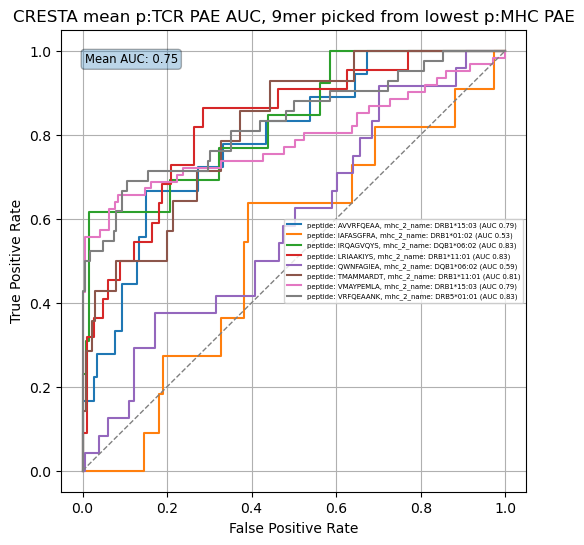

In [ ]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

plot_auc_per_antigen(
    pred_best_9mer_auc_df,
    id_cols=["peptide", "mhc_2_name"],
    title="CRESTA mean p:TCR PAE AUC, 9mer picked from lowest p:MHC PAE",
)